In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn.functional as F
from diffusers import UNet2DModel, DDPMScheduler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"
output_dir = "/content/drive/Shareddrives/Computer Vision/models-32"

model = UNet2DModel.from_pretrained(output_dir).to(device)
scheduler = DDPMScheduler.from_pretrained(output_dir)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def inference_demo(model, target_class_idx):
    inference_batch_size = 5000

    # 設定儲存路徑：generation_output/0001 (範例)
    # :04d 代表補零至 4 位數
    save_dir = f"/content/drive/Shareddrives/Computer Vision/generation_output/{target_class_idx:04d}"

    # 如果資料夾不存在，則建立它
    os.makedirs(save_dir, exist_ok=True)

    print(f"Start generating class: {target_class_idx} ...")

    # 生成雜訊與標籤
    image = torch.randn(inference_batch_size, 3, 32, 32).to(device)
    class_labels = torch.tensor([target_class_idx] * inference_batch_size).to(device)

    # 擴散模型生成迴圈
    for t in scheduler.timesteps:
        with torch.no_grad():
            model_output = model(
                image,
                t,
                class_labels=class_labels
            ).sample

        image = scheduler.step(model_output, t, image).prev_sample

    print(f"Image tensor shape: {image.shape}")

    output_images = image.cpu()
    output_images = (output_images / 2 + 0.5)
    output_images = output_images.clamp(0, 1)

    output_images_np = output_images.permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    for i in range(4):
      ax = axes[i]
      img_data = output_images_np[i]

      ax.imshow(img_data)
      ax.set_title(f"Class: {target_class_idx}")
      ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Saving images to: {save_dir} ...")

    for i in range(inference_batch_size):
        img_data = output_images_np[i]

        img_data_uint8 = (img_data * 255).astype(np.uint8)

        img_pil = Image.fromarray(img_data_uint8)

        save_path = os.path.join(save_dir, f"{i:03d}.png")
        img_pil.save(save_path)

    print(f"Successfully saved {inference_batch_size} images.")

Start generating class: 0 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


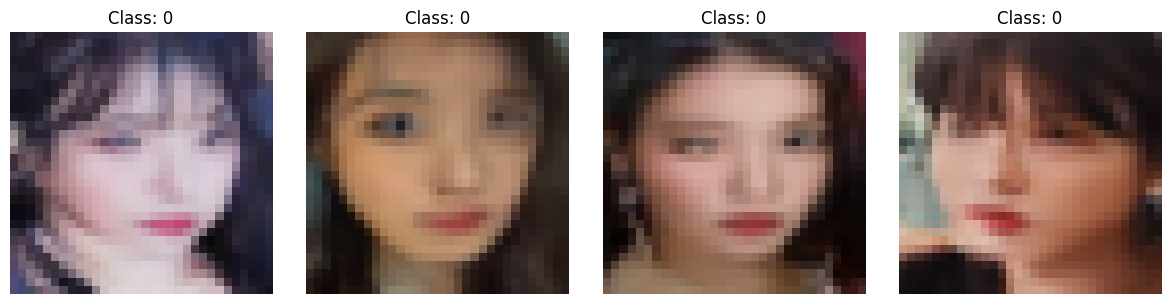

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0000 ...
Successfully saved 5000 images.
Start generating class: 1 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


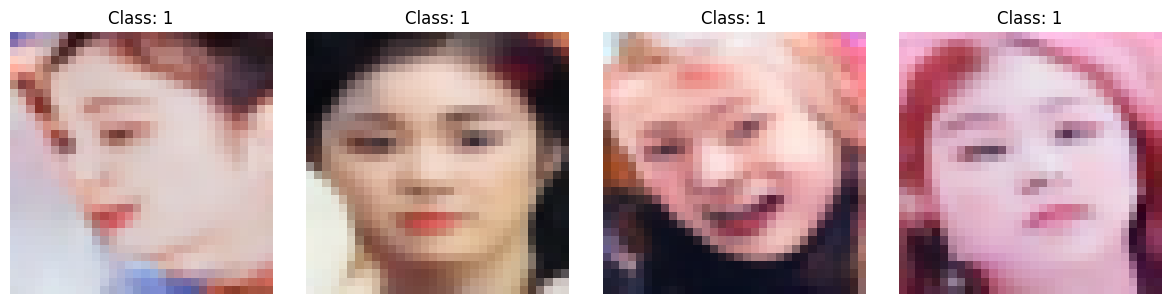

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0001 ...
Successfully saved 5000 images.
Start generating class: 2 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


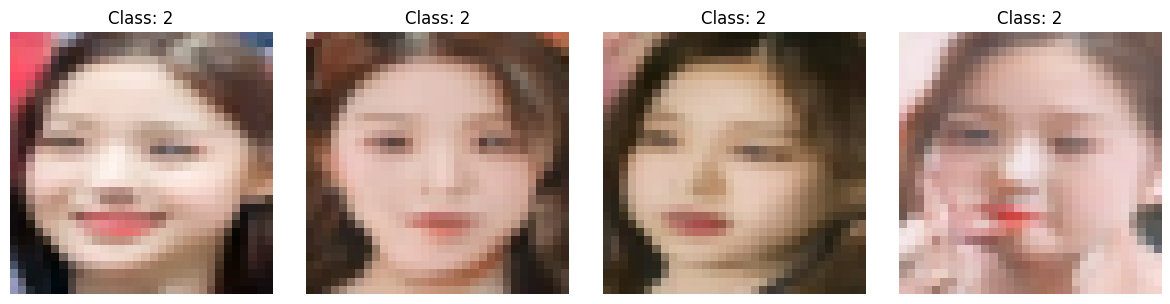

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0002 ...
Successfully saved 5000 images.
Start generating class: 3 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


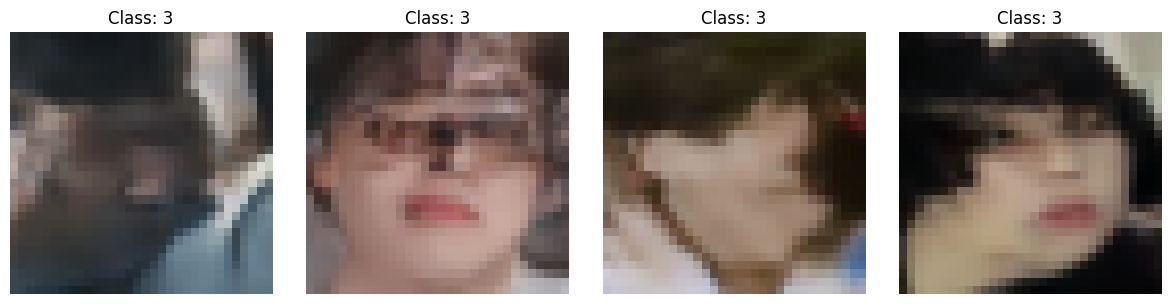

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0003 ...
Successfully saved 5000 images.
Start generating class: 4 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


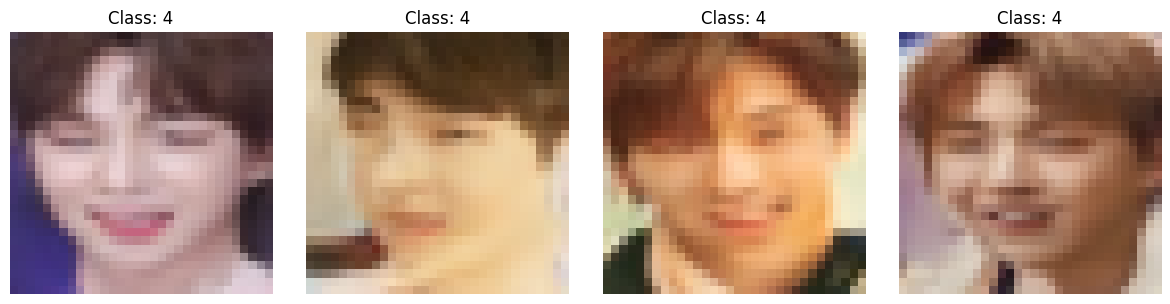

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0004 ...
Successfully saved 5000 images.
Start generating class: 5 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


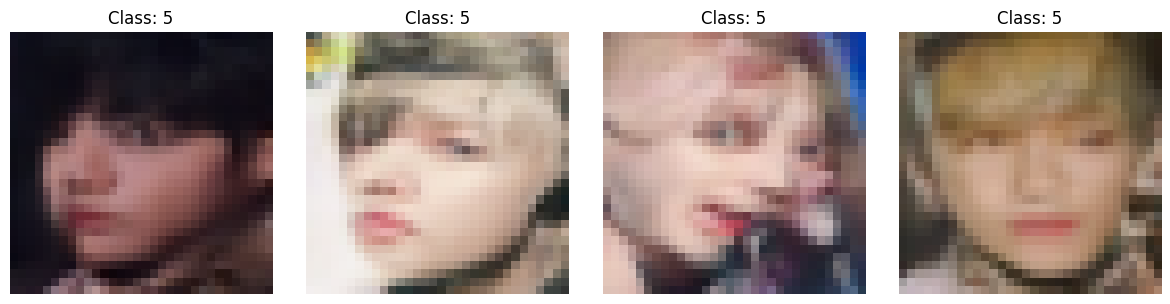

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0005 ...
Successfully saved 5000 images.
Start generating class: 6 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


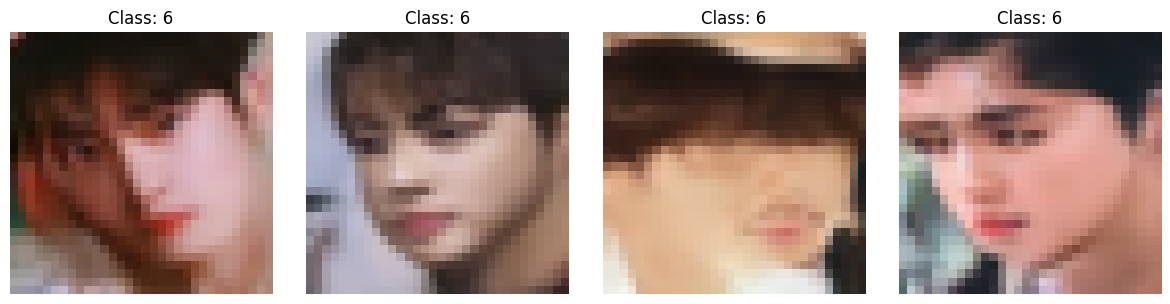

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0006 ...
Successfully saved 5000 images.
Start generating class: 7 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


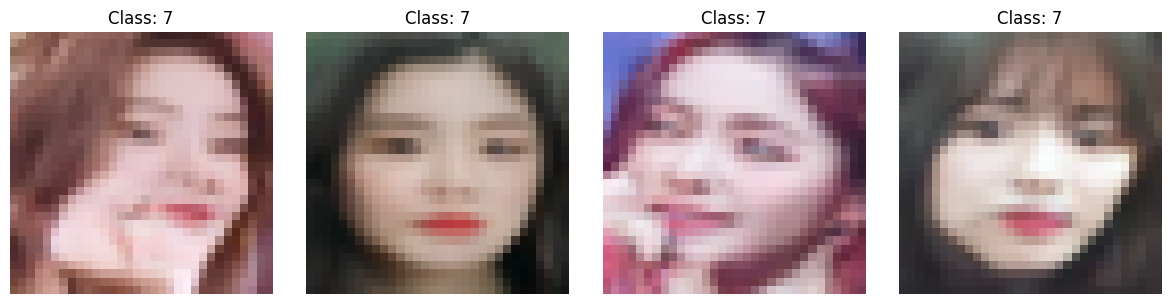

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0007 ...
Successfully saved 5000 images.
Start generating class: 8 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


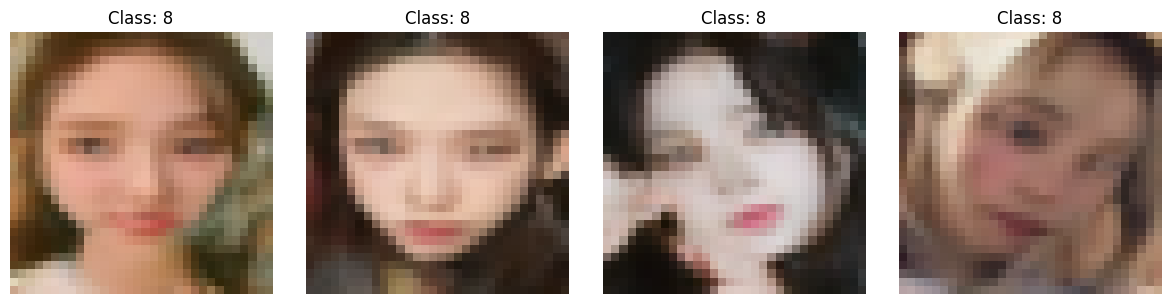

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0008 ...
Successfully saved 5000 images.
Start generating class: 9 ...
Image tensor shape: torch.Size([5000, 3, 32, 32])


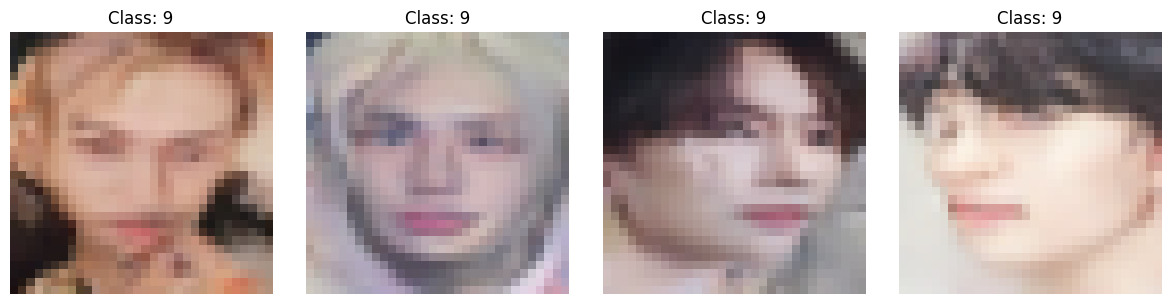

Saving images to: /content/drive/Shareddrives/Computer Vision/generation_output/0009 ...
Successfully saved 5000 images.


In [4]:
for i in range(10):
  inference_demo(model, i)